# What's New in TMAP

Once you have fit a TMAP, here is what you can do with it. Some of these features (incremental updates, tree paths, named distances) are things UMAP either cannot do or does not do as cleanly.

We continue with the MNIST data from `03_continuous_embeddings.ipynb`: same 10k subsample, same cosine metric. The first 8,000 rows are the training set. The last 2,000 are held out for the `add_points` and `transform` demos.

You will need scikit-learn (same as notebook 03).


train: (8000, 784), held: (2000, 784)


base embedding: (8000, 2)


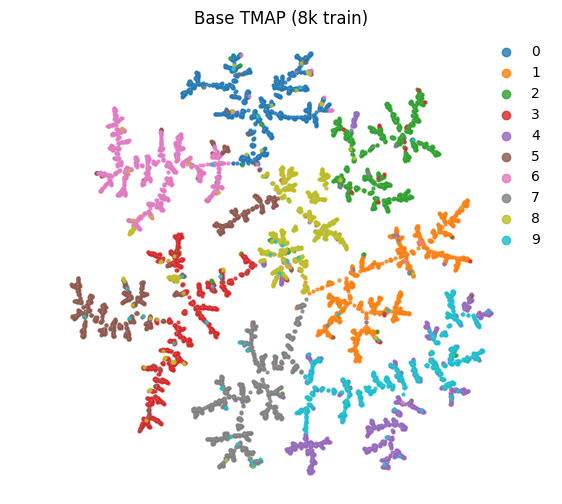

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

from tmap import TMAP

mnist = fetch_openml("mnist_784", version=1, as_frame=False, cache=True)
X_full = mnist.data.astype(np.float32) / 255.0
y_full = mnist.target.astype(int)

rng = np.random.default_rng(42)
idx = rng.choice(X_full.shape[0], size=10_000, replace=False)
X = X_full[idx]
y = y_full[idx]

X_train, X_held = X[:8000], X[8000:]
y_train, y_held = y[:8000], y[8000:]

print(f"train: {X_train.shape}, held: {X_held.shape}")

model = TMAP(metric="cosine", n_neighbors=20, seed=42, store_index=True).fit(X_train)
print(f"base embedding: {model.embedding_.shape}")

fig, ax = plt.subplots(figsize=(7, 6))
model.plot_static(color_by=y_train, color_map="tab10", point_size=4, ax=ax)
ax.set_title("Base TMAP (8k train)")
plt.show()


## 1. add_points

`add_points` inserts new data into a fitted model and extends the tree and the 2D embedding in place. The model mutates: `embedding_` grows, `tree_` grows.

Use this when you have new data arriving and you want it to integrate into the existing map without refitting from scratch.


embedding rows before: 8000, after: 10000


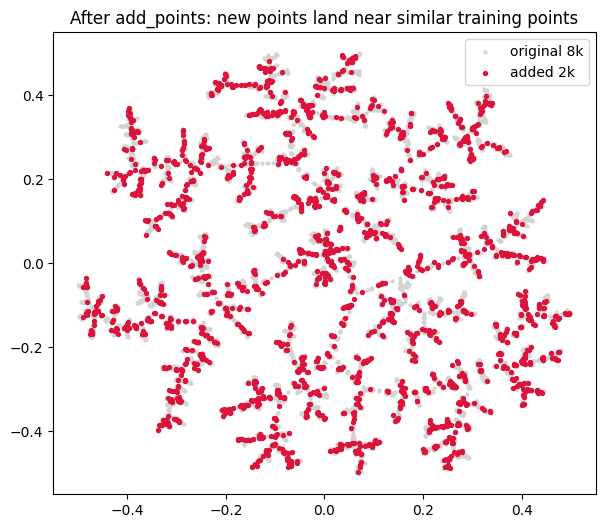

In [ ]:
before = model.embedding_.shape[0]
model.add_points(X_held)
after = model.embedding_.shape[0]
print(f"embedding rows before: {before}, after: {after}")

emb = model.embedding_
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(emb[:before, 0], emb[:before, 1], c="lightgray", s=4, label="original 8k")
ax.scatter(emb[before:, 0], emb[before:, 1], c="crimson", s=8, label="added 2k")
ax.legend()
ax.set_title("After add_points: new points land near similar training points")
plt.show()


## 2. transform

`transform` projects new points onto the map without changing the model. Useful for dashboards or pipelines where you want stable coordinates that do not drift each time new data arrives.

Returns coordinates only. Does not extend the tree, does not modify `embedding_`.


projected coords shape: (2000, 2)
model_t.embedding_ shape: (8000, 2) (unchanged)


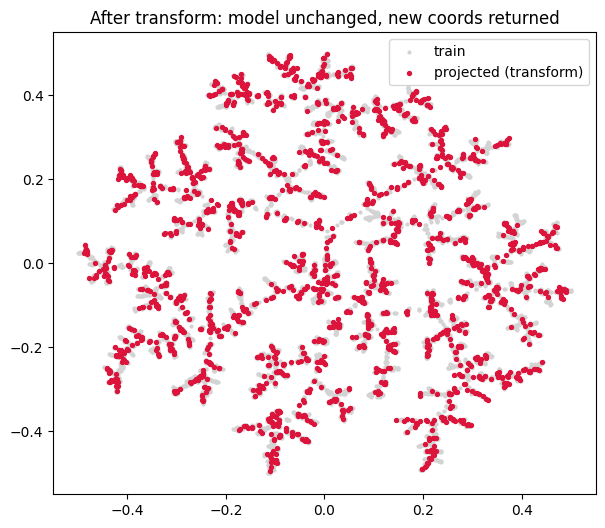

In [ ]:
# fit a fresh model so the comparison is clean
model_t = TMAP(metric="cosine", n_neighbors=20, seed=42, store_index=True).fit(X_train)
coords_held = model_t.transform(X_held)
print(f"projected coords shape: {coords_held.shape}")
print(f"model_t.embedding_ shape: {model_t.embedding_.shape} (unchanged)")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(model_t.embedding_[:, 0], model_t.embedding_[:, 1], c="lightgray", s=4, label="train")
ax.scatter(coords_held[:, 0], coords_held[:, 1], c="crimson", s=8, label="projected (transform)")
ax.legend()
ax.set_title("After transform: model unchanged, new coords returned")
plt.show()


## 3. Measuring kNN recall

When TMAP uses an approximate index (HNSW for cosine and euclidean, LSHForest for sparse Jaccard), the kNN graph is approximate. A reasonable question to ask is: how close is the approximate index to the exact answer?

We define recall@k as: for each point, what fraction of its true k nearest neighbors (computed by brute force in the original space) appear in TMAP's k nearest neighbors. A recall of 1.0 means TMAP's index found exactly the same neighbors as brute force. A recall of 0.5 means it missed half.

For cosine on MNIST at k=20, expect recall in the 0.95 to 0.99 range.


In [ ]:
from sklearn.neighbors import NearestNeighbors

k = 20
nn = NearestNeighbors(n_neighbors=k, metric="cosine").fit(X_train)
true_distances, true_neighbors = nn.kneighbors(X_train)

# tmap stores its kNN graph in model.graph_
tmap_neighbors = model_t.graph_.indices  # shape (8000, k)

def recall_at_k(true_nn, approx_nn, k):
    n = true_nn.shape[0]
    hits = 0
    for i in range(n):
        true_set = set(true_nn[i, :k].tolist())
        approx_set = set(approx_nn[i, :k].tolist())
        hits += len(true_set & approx_set)
    return hits / (n * k)

r10 = recall_at_k(true_neighbors, tmap_neighbors, 10)
r20 = recall_at_k(true_neighbors, tmap_neighbors, 20)
print(f"recall@10: {r10:.3f}")
print(f"recall@20: {r20:.3f}")


recall@10: 0.896
recall@20: 0.946


## 4. Tree exploration: path, distance, distances_from

The tree layout is what makes TMAP different from UMAP. Once a tree is built, every pair of points has a unique path along the tree, and the sum of edge weights along that path is a meaningful distance.

- `model.path(i, j)` returns the list of node indices along the tree path from `i` to `j`
- `model.distance(i, j)` returns the sum of edge weights along that path
- `model.distances_from(i)` returns tree distance from `i` to every other point, useful as pseudotime


path from idx 5 (class 0) to idx 24 (class 8)
path length: 16 nodes, tree distance: 1.700


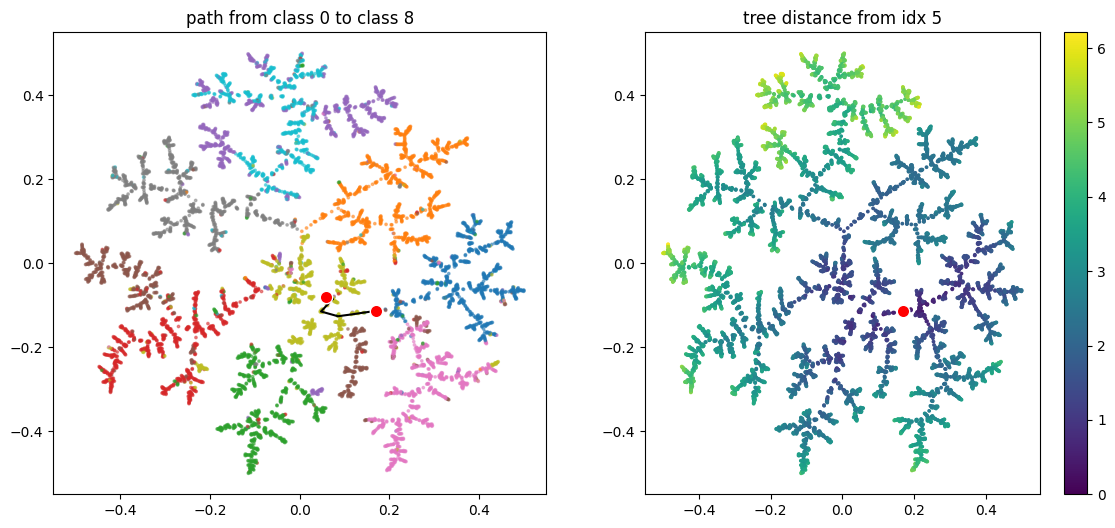

In [ ]:
# pick two points from different digit classes
i = int(np.where(y_train == 0)[0][0])
j = int(np.where(y_train == 8)[0][0])

path = model_t.path(i, j)
d = model_t.distance(i, j)
print(f"path from idx {i} (class {y_train[i]}) to idx {j} (class {y_train[j]})")
print(f"path length: {len(path)} nodes, tree distance: {d:.3f}")

# plot the path on the 2D embedding
emb = model_t.embedding_
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(emb[:, 0], emb[:, 1], c=y_train, cmap="tab10", s=3, alpha=0.5)
path_coords = emb[path]
ax.plot(path_coords[:, 0], path_coords[:, 1], color="black", linewidth=1.5)
ax.scatter([emb[i, 0], emb[j, 0]], [emb[i, 1], emb[j, 1]], c="red", s=80, edgecolor="white", zorder=5)
ax.set_title(f"path from class {y_train[i]} to class {y_train[j]}")

# pseudotime from i
ax = axes[1]
pseudotime = model_t.distances_from(i)
sc = ax.scatter(emb[:, 0], emb[:, 1], c=pseudotime, cmap="viridis", s=3)
ax.scatter(emb[i, 0], emb[i, 1], c="red", s=80, edgecolor="white", zorder=5)
ax.set_title(f"tree distance from idx {i}")
plt.colorbar(sc, ax=ax)
plt.show()


## 5. save and load

Persist a fitted model to disk and reload it later. Uses pickle under the hood.


In [ ]:
from pathlib import Path

path_pkl = Path("mnist_tmap.pkl")
model_t.save(path_pkl)
loaded = TMAP.load(path_pkl)

assert np.allclose(loaded.embedding_, model_t.embedding_)
print(f"saved to {path_pkl} ({path_pkl.stat().st_size / 1024:.1f} KB)")
print("roundtrip ok: embeddings match")

path_pkl.unlink()


saved to mnist_tmap.pkl (29342.6 KB)
roundtrip ok: embeddings match


## 6. External kNN

If you already have a kNN graph from another tool (FAISS, ScaNN, hand-built), pass it directly via `fit(knn_graph=...)`. TMAP skips the index step and goes straight to layout.


external kNN embedding: (8000, 2)


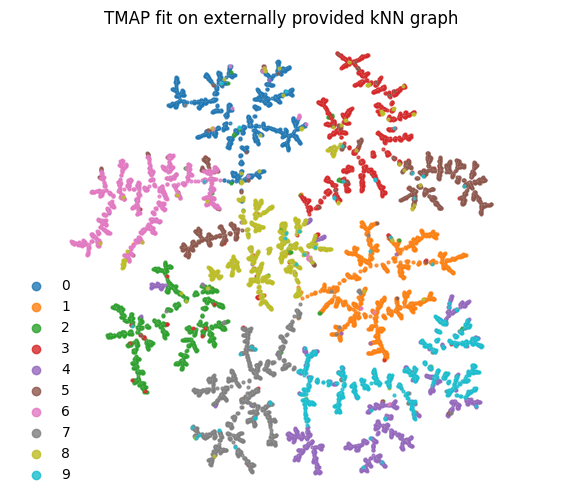

In [ ]:
from tmap.index.types import KNNGraph

# reuse the brute-force result from the recall section
external = KNNGraph.from_arrays(
    indices=true_neighbors.astype(np.int32),
    distances=true_distances.astype(np.float32),
)

external_model = TMAP(metric="cosine", n_neighbors=k, seed=42).fit(knn_graph=external)
print(f"external kNN embedding: {external_model.embedding_.shape}")

fig, ax = plt.subplots(figsize=(7, 6))
external_model.plot_static(color_by=y_train, color_map="tab10", point_size=4, ax=ax)
ax.set_title("TMAP fit on externally provided kNN graph")
plt.show()


## Where to go next

- `02_cheminformatics.ipynb`: chemistry workflows with binary fingerprints
- `10_protein_analysis.ipynb`: protein sequences and embeddings
- `05_single_cell.ipynb`: large sparse single-cell data
- `08_jscatter_demo.ipynb`: interactive notebook widgets
- `06_faq.ipynb`: short answers to common questions
